# Background: This project will look at the clustering differences between healthy brain tissue and brain tissue from patients with Alzheimer’s disease (AD) to identify the genes that drive that difference. AD is a progressive neurodegenerative disorder that impacts memory and thinking skills. The greatest risk factor is genetics, as having the presence of the APOE ε4 allele increases the likelihood of developing the disease. I reference the paper by Alkhatabi and Pushparaj for methods and obtained the publicly available dataset (accession number: GSE104704) from the Gene Expression Omnibus (GEO). This dataset includes samples from the lateral temporal lobe of eight healthy young brains, ten aged healthy brains, and twelve aged diseased brains. I will use volcano plots to determine what genes are primarily responsible for driving the genetic differences between the groups. Additionally, I will use a PCA plot to look for batch effects in the data. UMAP will then be used to analyze clustering of the data.  I expect two distinct clusters to form: one for the healthy brain samples and the other for the diseased brain samples. This should be due to the genetic differences in disease status and not that of age.
## Note: AI was used in this project as a debugger and to help adjust some of the code for the UMAP Plot, the K-mean clusters, and Silhouette Score Plots because we did not review how to make those plots in Python in our class or labs. The R code from GEO was used as a reference. 

In [1]:
#%pip install scanpy adjustText umap-learn statsmodels

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
from scipy import stats
import statsmodels.stats.multitest as smm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd
import warnings
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
warnings.filterwarnings('ignore')

In [3]:
#Load raw counts from GEO, used raw counts because that's what GEO used for their plots 
ADDirectory  = r'C:\Users\nbrec\Documents\2026 Spring Bio373 CompBio\Final Project\GSE104704_raw_counts_GRCh38.p13_NCBI.tsv\GSE104704_raw_counts_GRCh38.p13_NCBI.tsv'

In [6]:
#Load raw counts 
df = pd.read_csv(r'C:\Users\nbrec\Documents\2026 Spring Bio373 CompBio\Final Project\GSE104704_raw_counts_GRCh38.p13_NCBI.tsv\GSE104704_raw_counts_GRCh38.p13_NCBI.tsv', sep='\t', index_col='GeneID')
df.columns

#Verification step: look at what the dataset looks like 
print(f"Full dataset shape: {df.shape}") 
print(f"Columns: {df.columns.tolist}")

Full dataset shape: (39376, 30)
Columns: <bound method IndexOpsMixin.tolist of Index(['GSM2806214', 'GSM2806215', 'GSM2806216', 'GSM2806217', 'GSM2806218',
       'GSM2806219', 'GSM2806220', 'GSM2806221', 'GSM2806222', 'GSM2806223',
       'GSM2806224', 'GSM2806225', 'GSM2806226', 'GSM2806227', 'GSM2806228',
       'GSM2806229', 'GSM2806230', 'GSM2806231', 'GSM2806232', 'GSM2806233',
       'GSM2806234', 'GSM2806235', 'GSM2806236', 'GSM2806237', 'GSM2806238',
       'GSM2806239', 'GSM2806240', 'GSM2806241', 'GSM2806242', 'GSM2806243'],
      dtype='object')>


In [17]:
#IMPORTANT: You must normalize the raw data before doing anything with it

#Keep only genes where at least 2 samples have at least 10 counts. This step helps with noise and avoiding false positives
keep = (df >= 10).sum(axis=1) >= 2
df = df[keep]

#Verification Step: make sure filtering actually reduced the number of genes
print(f"After filtering: {df.shape}")

# Log2 normalize, makes data more normally distributed
dat = np.log10(df + 1)

#Verification Step: make sure the normalized values look reasonable
print(f"Sample of normalized values:\{df.iloc[:3, :3]}")

After filtering: (25709, 30)
Sample of normalized values:\           GSM2806214  GSM2806215  GSM2806216
GeneID                                       
100287102          10          10           5
653635            245         269         176
102466751           3           6           4


In [9]:
# Remove duplicate rows (genes), then transpose so samples are rows
dat_unique = dat.drop_duplicates()
dat_T = dat_unique.T   # shape: (30 samples x n_genes)

In [10]:
#Define the Groups
# GSM2806214-221 = young healthy controls (8 samples) and GSM2806222-231 = aged healthy controls (10 samples)
# I combined both groups into one healthy group for comparison against AD

healthy_ctrl_cols  = ['GSM2806214','GSM2806215','GSM2806216','GSM2806217',
                   'GSM2806218','GSM2806219','GSM2806220','GSM2806221','GSM2806222','GSM2806223','GSM2806224','GSM2806225',
                   'GSM2806226','GSM2806227','GSM2806228','GSM2806229',
                   'GSM2806230','GSM2806231']

# GSM2806232-243 = Alzheimer's disease patients (12 samples)
ad_cols         = ['GSM2806232','GSM2806233','GSM2806234','GSM2806235',
                   'GSM2806236','GSM2806237','GSM2806238','GSM2806239',
                   'GSM2806240','GSM2806241','GSM2806242','GSM2806243']
#create dataframes for the groups
healthy_data  = df[healthy_ctrl_cols].astype(float)
ADData     = df[ad_cols].astype(float)
gene       = df.index.tolist()

#Verification Step: Make sure the shapes match the expected sample counts 
print(f"AD:            {ADData.shape}")
print(f"healthy: {healthy_data.shape}")

AD:            (25709, 12)
healthy: (25709, 18)


# Making the Volcano Plot

Significant genes: 2870


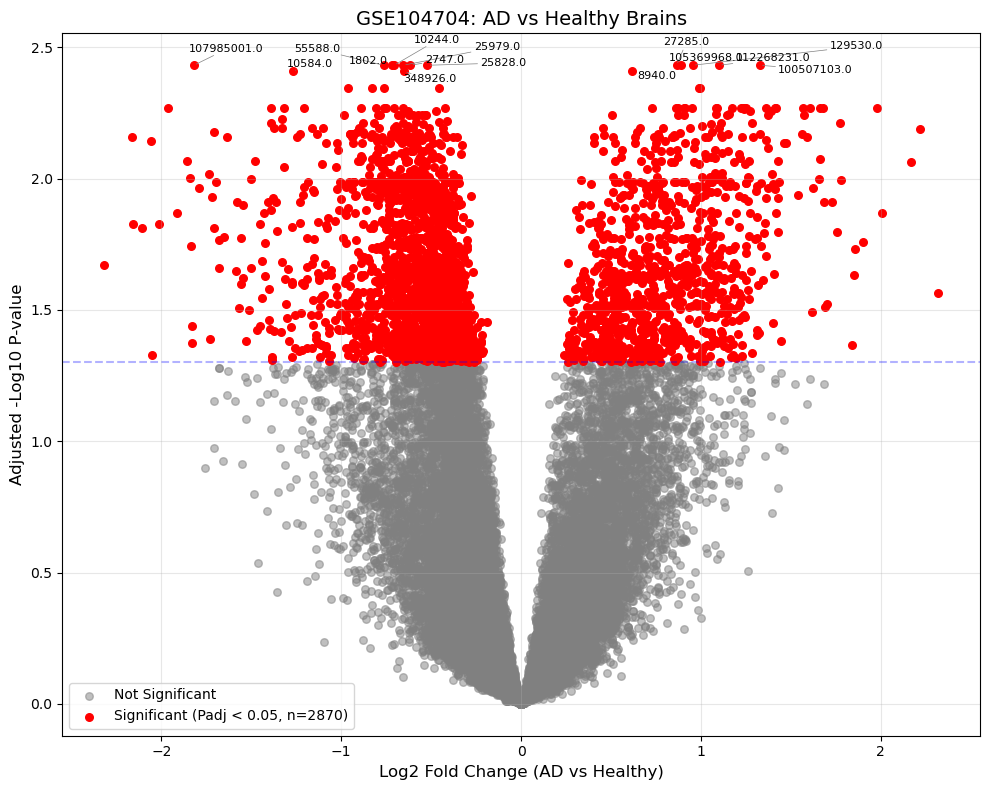

In [11]:
# Data was log2 normalized already so now just compute log2 fold change and p-values per gene
dat_log2 = df.copy()  
ad_log2   = dat_log2[ad_cols]
ctrl_log2 = dat_log2[healthy_ctrl_cols]

# Log2 Fold Change
log2fc = ad_log2.mean(axis=1) - ctrl_log2.mean(axis=1)

#Run Welch's t-test for each gene
pvals = []
for g in dat_log2.index:
    _, p = stats.ttest_ind(ad_log2.loc[g], ctrl_log2.loc[g], equal_var=False)
    pvals.append(p)

# FDR correction to control false discovery rate #AI Generated
_, pvals_adj, _, _ = multipletests(pvals, method='fdr_bh')

# Build results dataframe with fold change and adjusted p-values
results = pd.DataFrame({
    'gene':     dat_log2.index,
    'log2FC':   log2fc.values,
    'pval_adj': pvals_adj
})

# Convert adjusted p-values to -log10 #AI Generated
results['-log10p'] = -np.log10(results['pval_adj'] + 1e-300)

# Mark genes as significant if adjusted p-value <0.05
significant_points = results['pval_adj'] < 0.05
n_sig = significant_points.sum()

# Verification Step: Print counts to look at number of significant genes
print(f"Significant genes: {n_sig}")
print(f"Non-significant genes: {(~significant_points).sum()}")

# Plot Everything
fig, ax = plt.subplots(figsize=(10, 8))

# Gray = non-significant, red = significant
ax.scatter(results.loc[~significant_points, 'log2FC'],
           results.loc[~significant_points, '-log10p'],
           alpha=0.5, color='gray', s=30)
ax.scatter(results.loc[significant_points, 'log2FC'],
           results.loc[significant_points, '-log10p'],
           alpha=1, color='red', s=30)

# Make an adjusted p-value threshold
ax.axhline(y=-np.log10(0.05), color='blue', linestyle='--', alpha=0.3)

# Label top 15 most significant genes to research later
top_genes = results.nsmallest(15, 'pval_adj')
texts = []
for _, row in top_genes.iterrows():
    texts.append(ax.text(row['log2FC'], row['-log10p'], str(row['gene']), fontsize=8))
from adjustText import adjust_text
adjust_text(texts, arrowprops=dict(arrowstyle='-', color='grey', lw=0.5))

ax.legend(['Not Significant', f'Significant (Padj < 0.05, n={n_sig})'])
ax.grid(True, alpha=0.3)
ax.set_xlabel('Log2 Fold Change (AD vs Healthy)', fontsize=12)
ax.set_ylabel('Adjusted -Log10 P-value', fontsize=12)
ax.set_title('GSE104704: AD vs Healthy Brains', fontsize=14)
plt.tight_layout()
plt.savefig("volcano_plot.png", dpi=300)
plt.show()

# Making a PCA Plot

In [19]:
# Combine all of the data
allbrain = pd.concat([healthy_data, ADData], axis=1).T

# Handle any missing values
allbrain = allbrain.fillna(0)

# Filter low-expression genes
gene_mean = allbrain.mean(axis=0)
allbrain_filtered = allbrain.loc[:, gene_mean > 1]

# Verification Step: make sure the gene count is reduced before you filter
print(f"Genes used for PCA: {allbrain_filtered.shape[1]}")

Genes used for PCA: 25709


In [20]:
# Standardize the data 
scaler = StandardScaler()
allbrain_scaled = scaler.fit_transform(allbrain_log)

# Run PCA
pca = PCA(n_components=2)  # Using 2 components for visualization
pca_result = pca.fit_transform(allbrain_scaled)

# Create a dataframe with PCA results
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Group': ['Healthy'] * len(healthy_ctrl_cols) + ['AD'] * len(ad_cols)
})
# Standardize the data (important for PCA)
scaler = StandardScaler()
allbrain_scaled = scaler.fit_transform(allbrain_log)

# Run PCA
pca = PCA(n_components=2)  # Using 2 components for visualization
pca_result = pca.fit_transform(allbrain_scaled)

# Verification Step: Print explained variance
print(f"PC1 variance explained: {pca.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2 variance explained: {pca.explained_variance_ratio_[1]*100:.1f}%")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.1f}%")


PC1 variance explained: 25.1%
PC2 variance explained: 20.5%
Total variance explained: 45.6%


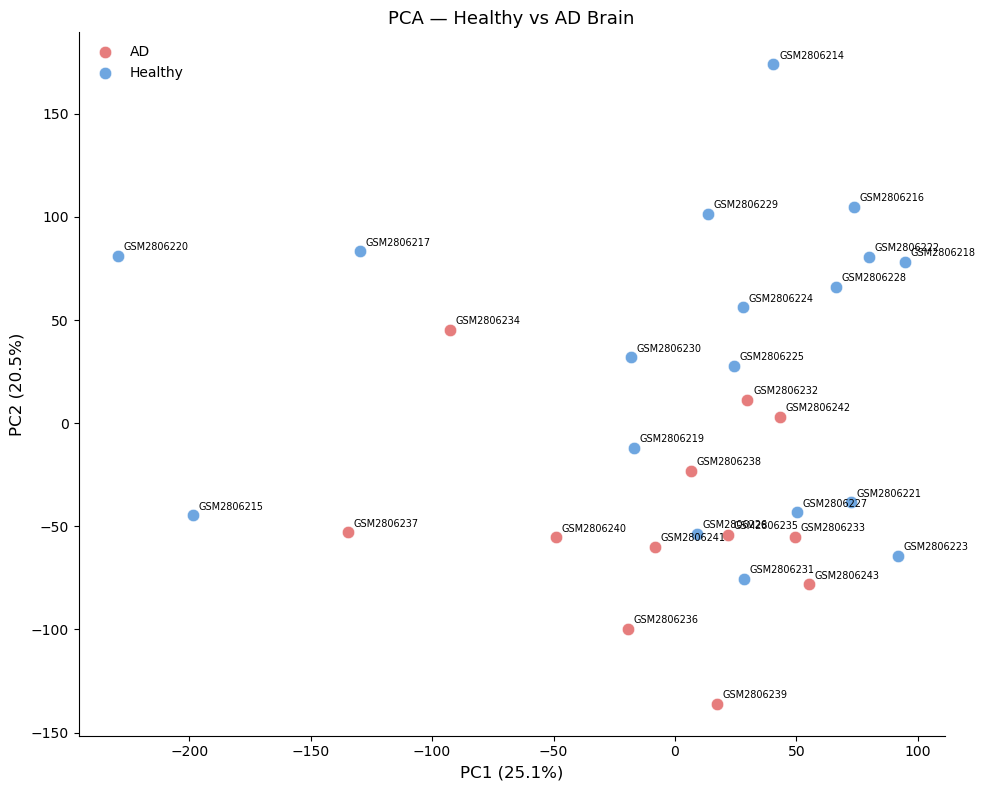

In [21]:
# Create a dataframe with PCA results
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Group': ['Healthy'] * len(healthy_ctrl_cols) + ['AD'] * len(ad_cols)
})

# Add IDs as index
pca_df.index = healthy_ctrl_cols + ad_cols

# Plot the results
fig, ax = plt.subplots(figsize=(10, 8))
colors = {'AD': '#E05C5C', 'Healthy': '#4A90D9'}
for group in ['AD', 'Healthy']:
    mask = pca_df['Group'] == group
    ax.scatter(pca_df.loc[mask, 'PC1'], pca_df.loc[mask, 'PC2'],
               c=colors[group], label=group, s=80, alpha=0.8,
               edgecolors='white', linewidths=0.5)

# Add labels for each point
for i, txt in enumerate(pca_df.index):
    ax.annotate(txt, (pca_df.iloc[i, 0], pca_df.iloc[i, 1]), 
                fontsize=7, xytext=(4, 4), textcoords='offset points')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('PCA — Healthy vs AD Brain', fontsize=13)
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

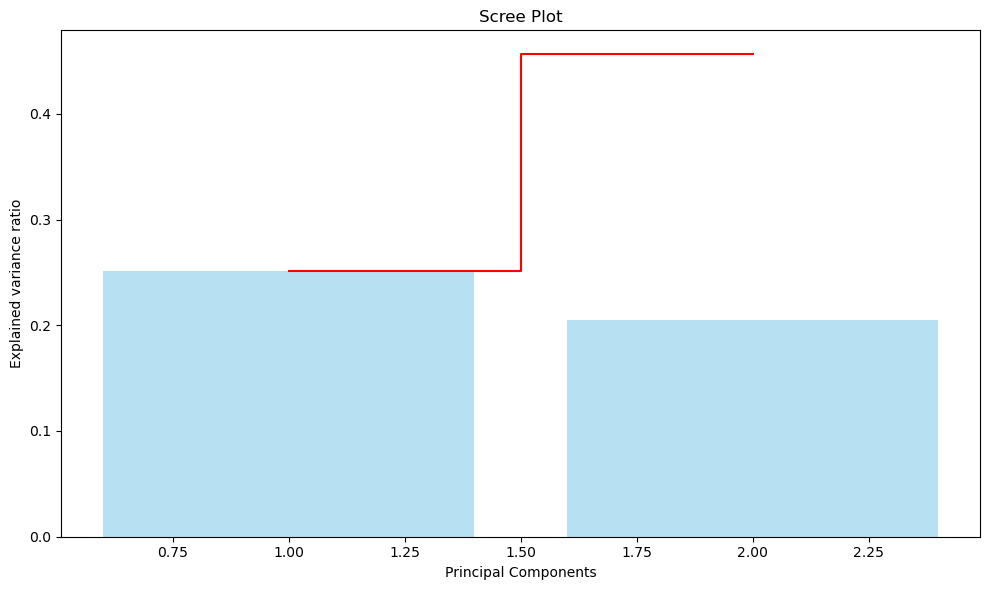

In [22]:
# Make a scree plot to visualize explained variance
plt.figure(figsize=(10, 6))
plt.bar(range(1, 3), pca.explained_variance_ratio_, alpha=0.6, color='skyblue')
plt.step(range(1, 3), np.cumsum(pca.explained_variance_ratio_), where='mid', color='red')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal Components')
plt.title('Scree Plot')
plt.tight_layout()
plt.show()

# Making a UMAP
## https://github.com/lmcinnes/umap was referenced when making this code 

In [13]:
#%pip install umap-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [25]:
import umap
import warnings
warnings.filterwarnings('ignore')

# Transpose data
AD_t = ADData.T
ctrl_t = healthy_data.T

# Combine groups into one matrix
combined = pd.concat([AD_t, ctrl_t], axis=0)

# Create list of group labels
labels = ['AD'] * len(AD_t) + ['Healthy'] * len(ctrl_t)

#Filter out low-expression genes to reduce noise
gene_means = combined.mean(axis=0)
combined = combined.loc[:, gene_means > 1]

#Standardize so all genes contribute equally to UMAP distances
data_scaled = StandardScaler().fit_transform(combined)

# Verification Step: Make sure everything that goes into the UMAP is correct 
print(f"Genes after filtering: {combined.shape[1]}")
print(f"Data into UMAP: {data_scaled.shape}")


Genes after filtering: 25709
Data into UMAP: (30, 25709)


In [26]:
#Fit UMAP # AI Generated
reducer   = umap.UMAP(n_neighbors=10, min_dist=0.3, metric='euclidean', random_state=42)
embedding = reducer.fit_transform(data_scaled)

#Verification Step: Shape should have 2 dimensions
print(f"Embedding shape: {embedding.shape}")

Embedding shape: (30, 2)


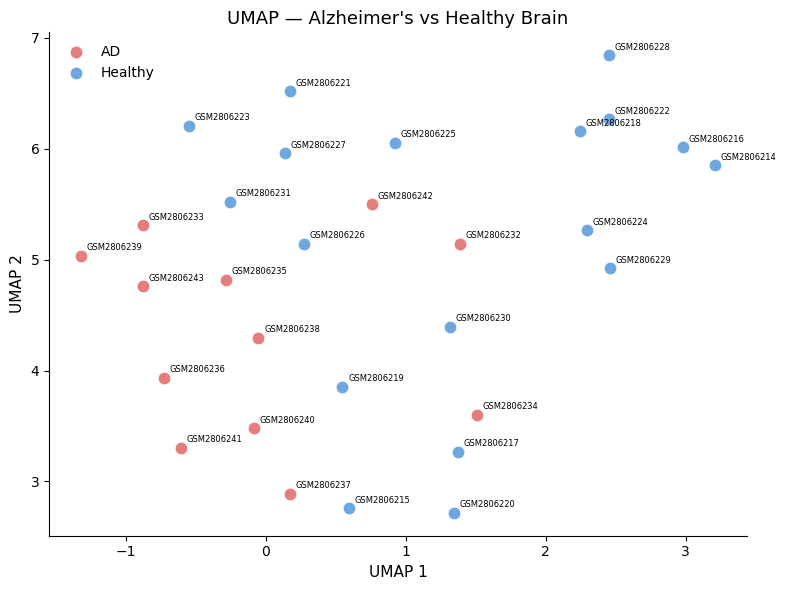

In [27]:
# Plot each group in a different color #AI Generated
fig, ax = plt.subplots(figsize=(8, 6))
colors = {'AD': '#E05C5C', 'Healthy': '#4A90D9'}
for group in ['AD', 'Healthy']:
    idx = [i for i, l in enumerate(labels) if l == group]
    ax.scatter(embedding[idx, 0], embedding[idx, 1],
               c=colors[group], label=group, s=80, alpha=0.8,
               edgecolors='white', linewidths=0.5)

# Label each point with its GSM sample ID
sample_ids = list(combined.index)
for i, sample_id in enumerate(sample_ids):
    ax.annotate(sample_id, (embedding[i, 0], embedding[i, 1]),
                fontsize=6, xytext=(4, 4), textcoords='offset points')

ax.set_title("UMAP — Alzheimer's vs Healthy Brain", fontsize=13)
ax.set_xlabel('UMAP 1', fontsize=11)
ax.set_ylabel('UMAP 2', fontsize=11)
ax.legend(frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("umap_AD_vs_healthy.png", dpi=300)
plt.show()

# K-Means Clustering and Silhouette Score
## Code was taken and adjusted from 

Silhouette Score: 0.387
K-Means cluster agreement with true labels: 63.3%


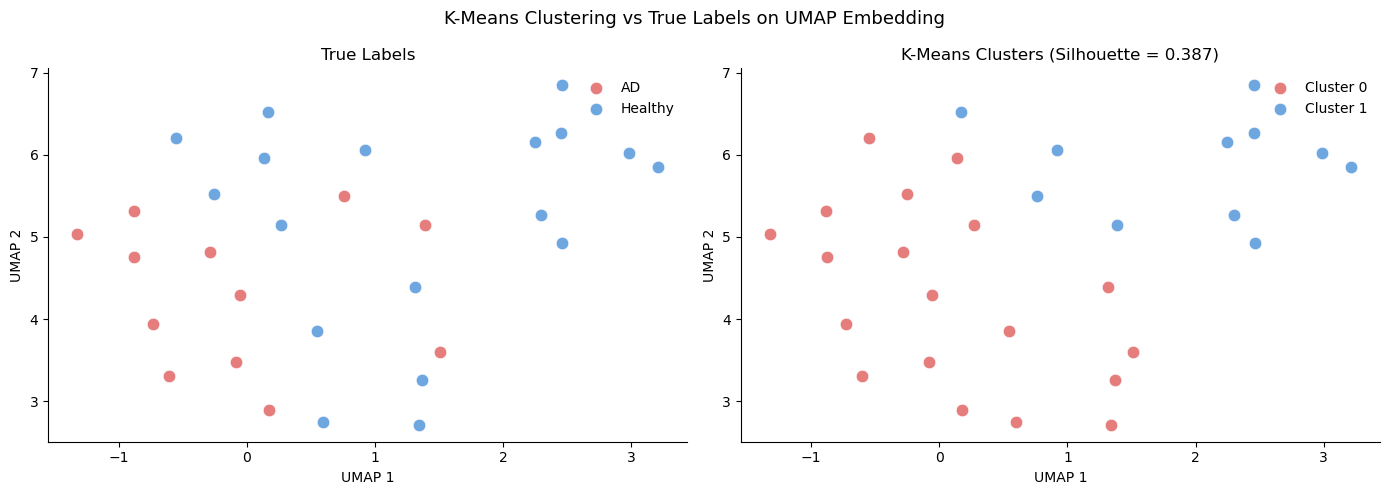

In [28]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Fit K-Means with 2 clusters (one for AD and one for Healthy)
kmeans = KMeans(n_clusters=2, random_state=42)
cluster_labels = kmeans.fit_predict(embedding)

# Silhouette score measures how well separated the clusters are
# Range is -1 to 1: closer to 1 = well separated, closer to 0 = overlapping
silhouette = silhouette_score(embedding, cluster_labels)
print(f"Silhouette Score: {silhouette:.3f}")

# Compare K-Means clusters to known AD/Healthy labels
true_labels = [0 if l == 'AD' else 1 for l in labels]

# Count how many samples K-Means correctly grouped with their true group #AI Generated 
match_forward = sum(c == t for c, t in zip(cluster_labels, true_labels))
match_flipped  = sum((1 - c) == t for c, t in zip(cluster_labels, true_labels))
accuracy = max(match_forward, match_flipped) / len(labels)
print(f"K-Means cluster agreement with true labels: {accuracy*100:.1f}%")

# Side-by-side comparison #AI Generated
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: true AD/Healthy labels
colors_true = {'AD': '#E05C5C', 'Healthy': '#4A90D9'}
for group in ['AD', 'Healthy']:
    idx = [i for i, l in enumerate(labels) if l == group]
    axes[0].scatter(embedding[idx, 0], embedding[idx, 1],
                    c=colors_true[group], label=group, s=80, alpha=0.8,
                    edgecolors='white', linewidths=0.5)
axes[0].set_title('True Labels', fontsize=12)
axes[0].set_xlabel('UMAP 1')
axes[0].set_ylabel('UMAP 2')
axes[0].legend(frameon=False)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# Right plot: K-Means assigned clusters
colors_kmeans = {0: '#E05C5C', 1: '#4A90D9'}
for cluster in [0, 1]:
    idx = [i for i, c in enumerate(cluster_labels) if c == cluster]
    axes[1].scatter(embedding[idx, 0], embedding[idx, 1],
                    c=colors_kmeans[cluster], label=f'Cluster {cluster}', s=80, alpha=0.8,
                    edgecolors='white', linewidths=0.5)
axes[1].set_title(f'K-Means Clusters (Silhouette = {silhouette:.3f})', fontsize=12)
axes[1].set_xlabel('UMAP 1')
axes[1].set_ylabel('UMAP 2')
axes[1].legend(frameon=False)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.suptitle("K-Means Clustering vs True Labels on UMAP Embedding", fontsize=13)
plt.tight_layout()
plt.savefig("kmeans_umap.png", dpi=300)
plt.show()